K-Nearest Neighbours
Step:
Given a data point:
1. Calculate its distance from all other data points in the dataset get the closest k points
2. Regression: Get the average of their values
3. Classification: Get the label with majority vote

In [21]:
import numpy as np
from collections import Counter
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [22]:
def eculidean_distane(x1,x2):
    distance=np.sqrt(np.sum((x1-x2)**2))
    return distance

In [23]:
class KNN:
    def __init__(self,k=3):
        self.k=k
    
    def fit(self,X,y):
        self.x_train=X
        self.y_train=y

    def predict(self,X):
        predictions=[self._predict(x) for x in X]
        return predictions
    
    def _predict(self,x):
        #compute the distance
        distance=[eculidean_distane(x,x_train) for x_train in self.x_train]

        #get the closest K
        k_indices=np.argsort(distance)[:self.k]
        k_nearest_labels=[self.y_train[i] for i in k_indices]
        
        # majority vote
        most_common=Counter(k_nearest_labels).most_common()

        return most_common[0][0]

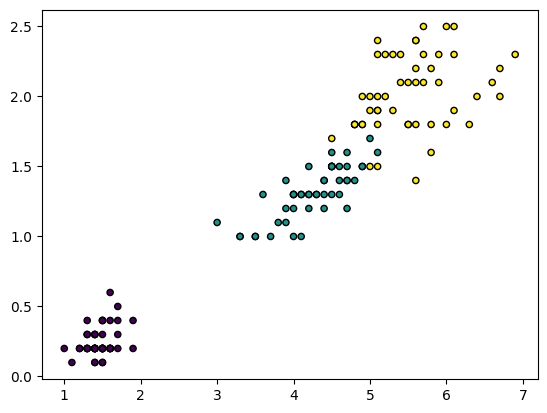

In [24]:
iris=datasets.load_iris()
X,y=iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
plt.figure()
plt.scatter(X[:,2], X[:,3], c=y, edgecolors='k', s=20)
plt.show()

In [39]:
clf=KNN(k=5)
clf.fit(X_train, y_train)
predictions=clf.predict(X_test)
print(predictions)

[np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(2), np.int64(0)]


In [40]:
acc=np.sum(predictions==y_test)/len(y_test)
print(acc)

0.9666666666666667
